# Tutorial 4: SurEau Basic run 


## Load modules

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from plant_hydraulics.run_sureau import run_sureau
from plant_hydraulics.parameter_classes import (
    SurEauVegetationParams,
    SurEauSoilParams,
    SurEauModelOptions,
)
 
 

ModuleNotFoundError: No module named 'plant_hydraulics'

## Climate

In [ ]:
from plant_hydraulics.utils import (
    load_example_data,
)

In [ ]:
climate_df = load_example_data("climat_example.csv", sep=";")

## Initialize soil parameters


In [ ]:
soil_params = SurEauSoilParams()
 

soil_params.depth = np.array([0.2, 0.8, 2.0])
soil_params.RFC = np.array([75, 75, 75])

## Initialize vegetation parameters

In [ ]:
# Create with defaults (Q. ilex)
veg_params = SurEauVegetationParams()

In [ ]:
# Leaf area index (m²/m²). Higher = more transpiration.
veg_params.LAI_max = 4.5       
veg_params.foliage = "Evergreen"  
veg_params.transpiration_model = "Jarvis"  

# ψ at 50% loss of leaf conductance (MPa) 
veg_params.P50_VC_leaf = -3.4

# ψ at 50% loss of stem conductance (MPa)   
veg_params.P50_VC_stem = -3.4

# Steepness of vulnerability sigmoid (%/MPa)   
veg_params.slope_VC_leaf = 60   

# ψ at 12% stomatal closure (MPa)
veg_params.P12_gs = -2.07

# ψ at 88% stomatal closure (MPa)       
veg_params.P88_gs = -2.62       

# Whole-plant conductance (mmol/m²/s/MPa)
veg_params.k_plant_init = 0.62  

# At 20°C (mmol/m²/s)
veg_params.gmin20 = 4.0

# Temperature where cuticle melts (°C)         
veg_params.TPhase_gmin = 37.5

# Q10 above TPhase    
veg_params.Q10_2_gmin = 4.8     
 

## Set modeling options

In [ ]:
opts = SurEauModelOptions(
    # Simulation period — must match years in the climate DataFrame
    year_start=1990,
    year_end=1990,
 
    # Site location — used for daylength and solar geometry
    # 43.9°N = southern France (Montpellier area)
    latitude=43.9,
 
    # Elevation affects psychrometric constant in ETP calculation
    elevation=0,
 
    # Print progress to console
    print_progress=True,
)
 

## Run the model

In [ ]:
results = run_sureau(
    climate_df=climate_df,
    veg_params=veg_params,
    soil_params=soil_params,
    opts=opts,
    deep_water=False,  # Set True to keep deepest layer at field capacity
)


Year 1990 Day   2

Year 1990 complete. 


##  Plot results 

  Plotting DOY 209 (July 28, 1990)
  Hours available: 24
  Min ψ_LSym this day: -2.503 MPa
  Min regul_fact: 0.241


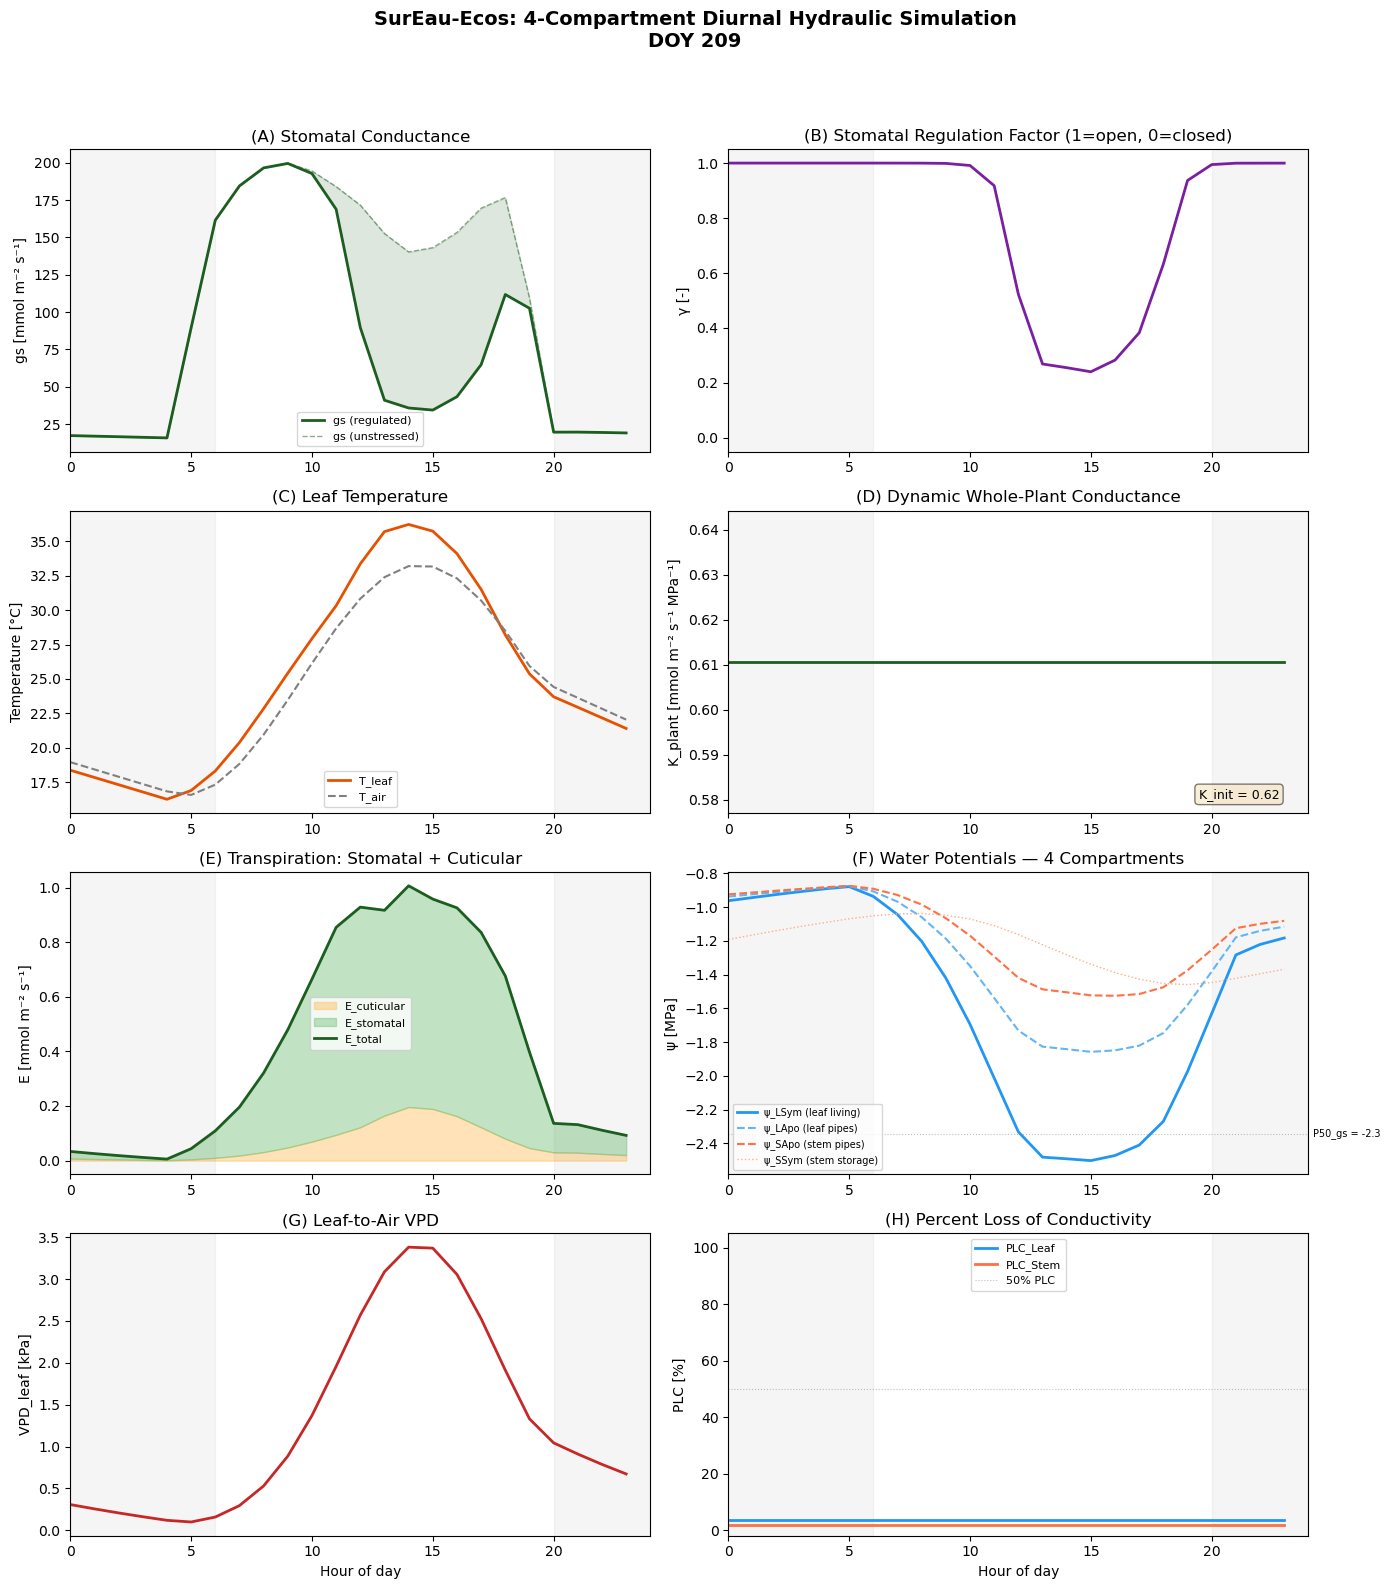

In [ ]:
#| echo: false

target_doy = 209
day = results[results["doy"] == target_doy].copy()
hours = day["time"].values
 
print(f"  Plotting DOY {target_doy} (July 28, 1990)")
print(f"  Hours available: {len(hours)}")
print(f"  Min ψ_LSym this day: {day['psi_LSym'].min():.3f} MPa")
print(f"  Min regul_fact: {day['regul_fact'].min():.3f}")
 
# ── Colour scheme ────────────────────────────────────────────────────────
c_LSym = '#2196F3'   # blue — leaf symplasm (living cells)
c_LApo = '#64B5F6'   # light blue — leaf apoplasm (xylem pipes)
c_SApo = '#FF7043'   # orange — stem apoplasm (trunk pipes)
c_SSym = '#FFAB91'   # light orange — stem symplasm (trunk storage)
c_total = '#1B5E20'  # dark green — total / canopy-level
 
def shade_night(ax):
    """Gray shading for nighttime hours (before sunrise, after sunset)."""
    ax.axvspan(0, 6, alpha=0.08, color='gray')
    ax.axvspan(20, 24, alpha=0.08, color='gray')
 
# ── Create the figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('SurEau-Ecos: 4-Compartment Diurnal Hydraulic Simulation\n'
             f'DOY {target_doy}',
             fontsize=14, fontweight='bold', y=0.99)
 
# ── (A) Stomatal Conductance ─────────────────────────────────────────────
# Shows gs_lim (water-limited, solid) vs gs_bound/γ (unstressed, dashed).
# The gap between curves = water stress cost.
ax = axes[0, 0]
gs_regulated = day['gs_lim'].values
gs_unstressed = gs_regulated / (day['regul_fact'].values + 1e-10)
ax.fill_between(hours, gs_regulated, gs_unstressed, alpha=0.15, color=c_total)
ax.plot(hours, gs_regulated, color=c_total, lw=2, label='gs (regulated)')
ax.plot(hours, gs_unstressed, color=c_total, lw=1, ls='--', alpha=0.5,
        label='gs (unstressed)')
shade_night(ax)
ax.set_ylabel('gs [mmol m⁻² s⁻¹]')
ax.set_title('(A) Stomatal Conductance')
ax.legend(fontsize=8)
ax.set_xlim(0, 24)
 
# ── (B) Stomatal Regulation Factor ───────────────────────────────────────
# γ = 1 → stomata fully open. γ = 0 → fully closed.
# Driven by the sigmoid (Eq. 34) applied to ψ_LSym.
ax = axes[0, 1]
ax.plot(hours, day['regul_fact'].values, color='#7B1FA2', lw=2)
shade_night(ax)
ax.set_ylabel('γ [-]')
ax.set_title('(B) Stomatal Regulation Factor (1=open, 0=closed)')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(0, 24)
 
# ── (C) Leaf Temperature ────────────────────────────────────────────────
# T_leaf > T_air when stomata close (less transpirational cooling).
# Energy balance: Penman-Monteith linearization (compute_T_leaf).
ax = axes[1, 0]
ax.plot(hours, day['leaf_temperature'].values, color='#E65100', lw=2, label='T_leaf')
ax.plot(hours, day['T_air'].values, color='gray', lw=1.5, ls='--', label='T_air')
shade_night(ax)
ax.set_ylabel('Temperature [°C]')
ax.set_title('(C) Leaf Temperature')
ax.legend(fontsize=8)
ax.set_xlim(0, 24)
 
# ── (D) Dynamic Whole-Plant Conductance ──────────────────────────────────
# K_plant = 1/(1/Σk_root + 1/k_stem-leaf + 1/k_leaf-sym) (Eq. 13).
# Decreases as PLC increases from cavitation.
ax = axes[1, 1]
ax.plot(hours, day['k_plant'].values, color=c_total, lw=2)
shade_night(ax)
ax.set_ylabel('K_plant [mmol m⁻² s⁻¹ MPa⁻¹]')
ax.set_title('(D) Dynamic Whole-Plant Conductance')
ax.text(0.95, 0.05, f'K_init = {veg_params.k_plant_init}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlim(0, 24)
 
# ── (E) Transpiration: Stomatal + Cuticular ──────────────────────────────
# E_total = E_lim (stomatal, green) + E_min (cuticular, orange).
# Cuticular transpiration is the "unstoppable leak" that drives mortality.
ax = axes[2, 0]
E_cuticular = day['E_min'].values
E_total = day['E_lim'].values + E_cuticular
ax.fill_between(hours, 0, E_cuticular, alpha=0.4, color='#FFB74D', label='E_cuticular')
ax.fill_between(hours, E_cuticular, E_total, alpha=0.4, color='#66BB6A', label='E_stomatal')
ax.plot(hours, E_total, color=c_total, lw=2, label='E_total')
shade_night(ax)
ax.set_ylabel('E [mmol m⁻² s⁻¹]')
ax.set_title('(E) Transpiration: Stomatal + Cuticular')
ax.legend(fontsize=8)
ax.set_xlim(0, 24)
 
# ── (F) Water Potentials — 4 Compartments ────────────────────────────────
# The heart of SurEau: 4 interconnected water tanks.
#   ψ_LSym (blue) — leaf living cells. Drops most (transpiration pulls here).
#   ψ_LApo (light blue) — leaf xylem pipes. Follows ψ_LSym closely.
#   ψ_SApo (orange) — stem pipes. Drops less (buffered by stem storage).
#   ψ_SSym (light orange) — stem storage. Most buffered of all.
ax = axes[2, 1]
ax.plot(hours, day['psi_LSym'].values, color=c_LSym, lw=2,
        label='ψ_LSym (leaf living)')
ax.plot(hours, day['psi_LApo'].values, color=c_LApo, lw=1.5, ls='--',
        label='ψ_LApo (leaf pipes)')
ax.plot(hours, day['psi_SApo'].values, color=c_SApo, lw=1.5, ls='--',
        label='ψ_SApo (stem pipes)')
ax.plot(hours, day['psi_SSym'].values, color=c_SSym, lw=1, ls=':',
        label='ψ_SSym (stem storage)')
# Mark P50_gs (midpoint of stomatal closure)
P50_gs = (veg_params.P12_gs + veg_params.P88_gs) / 2
ax.axhline(P50_gs, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.text(24.2, P50_gs, f'P50_gs = {P50_gs:.1f}', fontsize=7, va='center')
shade_night(ax)
ax.set_ylabel('ψ [MPa]')
ax.set_title('(F) Water Potentials — 4 Compartments')
ax.legend(fontsize=7, loc='lower left')
ax.set_xlim(0, 24)
 
# ── (G) Leaf-to-Air VPD ─────────────────────────────────────────────────
# The driving force for transpiration. Includes Kelvin equation
# correction for reduced water activity at negative ψ.
ax = axes[3, 0]
ax.plot(hours, day['VPD'].values, color='#C62828', lw=2)
shade_night(ax)
ax.set_ylabel('VPD_leaf [kPa]')
ax.set_title('(G) Leaf-to-Air VPD')
ax.set_xlabel('Hour of day')
ax.set_xlim(0, 24)
 
# ── (H) Percent Loss of Conductivity ────────────────────────────────────
# PLC from the sigmoidal vulnerability curve (Eq. 15).
# Irreversible: once pipes burst, they stay broken.
# Low PLC (~2%) here because ψ_LApo stays well above P50_VC (-3.4 MPa).
ax = axes[3, 1]
ax.plot(hours, day['PLC_leaf'].values, color=c_LSym, lw=2, label='PLC_Leaf')
ax.plot(hours, day['PLC_stem'].values, color=c_SApo, lw=2, label='PLC_Stem')
ax.axhline(50, color='gray', ls=':', lw=0.8, alpha=0.5, label='50% PLC')
shade_night(ax)
ax.set_ylabel('PLC [%]')
ax.set_title('(H) Percent Loss of Conductivity')
ax.legend(fontsize=8)
ax.set_ylim(-2, 105)
ax.set_xlabel('Hour of day')
ax.set_xlim(0, 24)
 
plt.tight_layout(rect=[0, 0, 1, 0.96])
 